# Quantum Phase Estimation — Demo

Walks through `algorithms.qpe` end to end: build the oracle for a known
phase, visualize the circuit and its measurement histogram, estimate the
phase exactly (terminating binary fraction) and approximately
(non-terminating), and see how precision improves with more counting
qubits.

See [../math.md](../math.md) for the theory — including the explicit
connection to [../../shor/](../../shor/)'s order-finding circuit — and
[../paper.md](../paper.md) for the circuit derivation this notebook
exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from qiskit.circuit import QuantumCircuit

from algorithms.qpe import visualization
from algorithms.qpe.circuit import build_qpe_circuit
from algorithms.qpe.execution import AerExecutor
from algorithms.qpe.implementation import estimate_phase
from algorithms.qpe.oracles import PhaseGateOracle

theta = 0.25  # exact in 2 bits: 0.25 = 0.01 in binary
eigenstate_prep = QuantumCircuit(1)
eigenstate_prep.x(0)  # |1> is P(2*pi*theta)'s eigenstate
executor = AerExecutor()
print(f"True theta: {theta}")

True theta: 0.25


## The circuit

`H` on the counting register, prepare the eigenstate, controlled powers of
`U = P(2*pi*theta)`, inverse QFT (reused directly from `arithmetic/qft.py`),
measure the counting register.

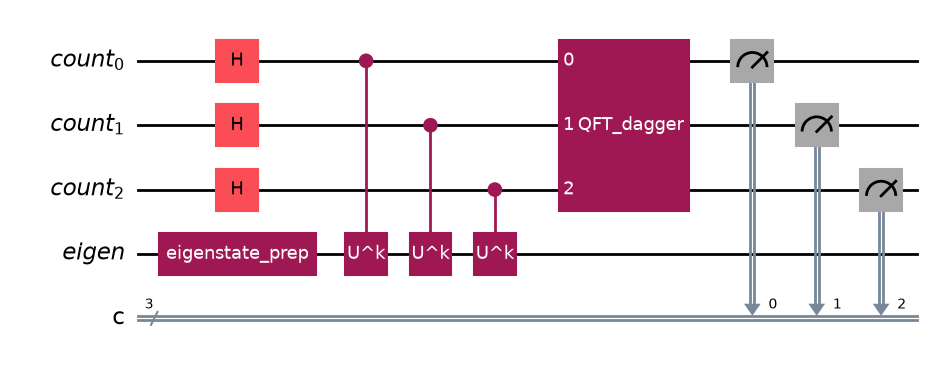

In [3]:
oracle = PhaseGateOracle(theta)
circuit = build_qpe_circuit(n_count=3, oracle=oracle, eigenstate_prep=eigenstate_prep)
visualization.circuit_figure(circuit)

## Running it

Since `theta=0.25` has an exact 2-bit binary expansion, this should measure
the same bitstring with certainty even with `n_count=3` counting qubits.

{'010': 100}


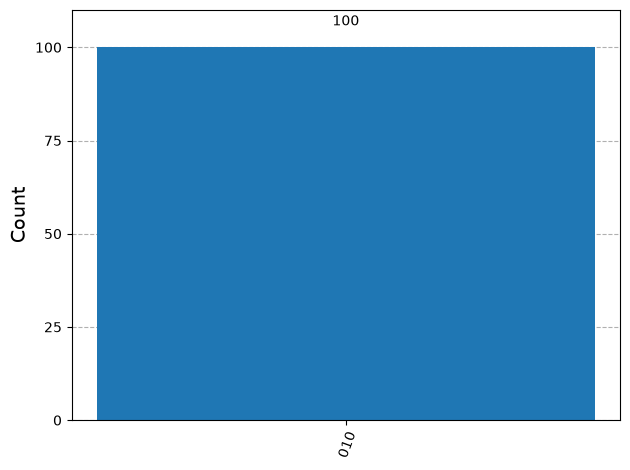

In [4]:
counts = executor.run(circuit, shots=100)
print(counts)
visualization.plot_measurement_histogram(counts)

## `estimate_phase`: exact case

In [5]:
result = estimate_phase(oracle, eigenstate_prep, n_count=3)
print(f"estimate_phase recovered: {result} (expected {theta})")
assert result == theta

estimate_phase recovered: 0.25 (expected 0.25)


## `estimate_phase`: non-terminating case

`theta=0.1` has no exact finite binary expansion, so precision improves
(but not perfectly monotonically on any single run — see
[benchmarks/qpe.md](../../../benchmarks/qpe.md)) as `n_count` grows.

In [6]:
theta2 = 0.1
oracle2 = PhaseGateOracle(theta2)
for n_count in [3, 5, 8, 10, 12]:
    estimated = estimate_phase(oracle2, eigenstate_prep, n_count)
    error = abs(estimated - theta2)
    tolerance = 1 / 2**n_count
    print(
        f"n_count={n_count:2d}: estimated={estimated:.6f}  "
        f"error={error:.6f}  tolerance={tolerance:.6f}"
    )

n_count= 3: estimated=0.125000  error=0.025000  tolerance=0.125000
n_count= 5: estimated=0.062500  error=0.037500  tolerance=0.031250


n_count= 8: estimated=0.097656  error=0.002344  tolerance=0.003906


n_count=10: estimated=0.099609  error=0.000391  tolerance=0.000977


n_count=12: estimated=0.100098  error=0.000098  tolerance=0.000244
